# Project overview


Recent flooding in New York City motivated a simple visualization project to visually explore how basic city attributes (land use, building height) relate to flood vulnerability. This notebook presents minimal, intuitive overlays without analytical modeling or inference.



Data source: New York City's Flood Vulnerability Index from NYC Open Data

https://data.cityofnewyork.us/Environment/New-York-City-s-Flood-Vulnerability-Index/mrjc-v9pm/about_data

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [10]:
pluto = gpd.read_file("../../Data/nyc_mappluto_25v1_1_shp/MapPLUTO.shp")
pluto.head()

,Borough,Block,Lot,CD,BCT2020,BCTCB2020,CT2010,CB2010,SchoolDist,Council,...,FIRM07_FLA,PFIRM15_FL,Version,DCPEdited,Latitude,Longitude,Notes,Shape_Leng,Shape_Area,geometry
0,MN,1,10,101,1000500,10005000003,5,1000,02,1,...,1,1,25v1.1,None,40.688774,-74.018704,None,0.0,7.414502e+06,"POLYGON ((980898.728 191409.779, 980881.798 19..."
1,MN,1,101,101,1000100,10001001001,1,1001,02,1,...,None,1,25v1.1,None,40.689920,-74.045337,None,0.0,5.018973e+05,"MULTIPOLYGON (((972428.829 190679.175, 972443...."
2,MN,1,201,101,1000100,10001001000,1,1000,02,1,...,None,1,25v1.1,None,40.698188,-74.041329,None,0.0,1.148539e+06,"POLYGON ((973648.066 193711.894, 973525.342 19..."
3,MN,2,1,101,1000900,10009001022,9,1025,02,1,...,1,1,25v1.1,t,40.700369,-74.012911,None,0.0,1.008250e+05,"POLYGON ((980609.55 194220.422, 980608.726 194..."
4,MN,2,2,101,1000900,10009001022,9,1025,02,1,...,1,1,25v1.1,None,40.700550,-74.011588,None,0.0,8.724419e+04,"POLYGON ((980854.138 194531.437, 980823.199 19..."


## Overlay FVI on MapPLUTO

In [15]:
import pandas as pd
from shapely import wkt
fvi = pd.read_csv("New_York_City_s_Flood_Vulnerability_Index.csv")
fvi["geometry"] = fvi["the_geom"].apply(wkt.loads)
fvi_gdf = gpd.GeoDataFrame(fvi, geometry="geometry", crs="EPSG:4326").to_crs(pluto.crs)

(np.float64(905418.5751214505),
 np.float64(1075046.302603197),
 np.float64(112410.87610433102),
 np.float64(280449.29290821555))

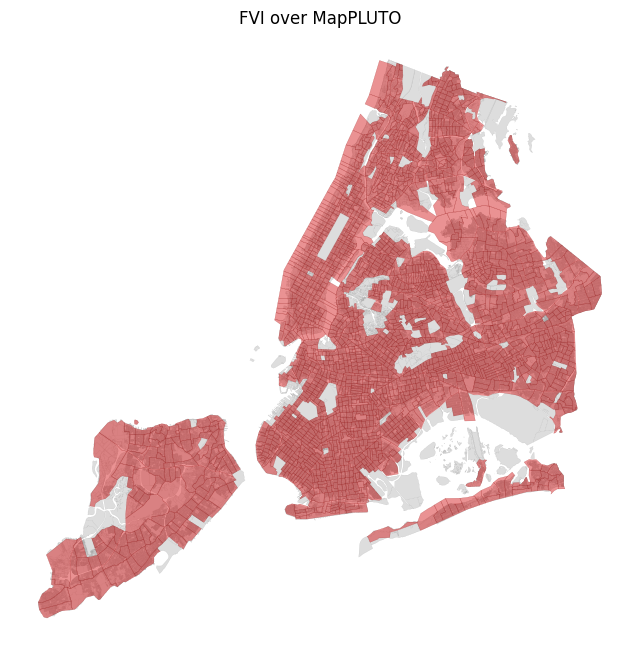

In [16]:
ax = pluto.plot(figsize=(8, 8), color="#dddddd", linewidth=0.1, edgecolor="#aaaaaa")
fvi_gdf.plot(ax=ax, color="#d62728", alpha=0.5, linewidth=0.2, edgecolor="#8b0000")
plt.title("FVI over MapPLUTO")
plt.axis("off")

## FVI visual overlays with LandUse and building height


These maps offer an intuitive, non-analytical look at how flood vulnerability relates to land use and building height.

In [20]:
fvi_col = "FVI_storm_surge_present" if "FVI_storm_surge_present" in fvi_gdf.columns else fvi_gdf.columns[[c.startswith("FVI_") for c in fvi_gdf.columns]][0]
fvi_gdf[fvi_col] = pd.to_numeric(fvi_gdf[fvi_col], errors="coerce")
fvi_low = fvi_gdf[fvi_gdf[fvi_col] <= 2]
fvi_high = fvi_gdf[fvi_gdf[fvi_col] >= 4]

(np.float64(905418.5751214505),
 np.float64(1075046.302603197),
 np.float64(112410.87610433102),
 np.float64(280449.29290821555))

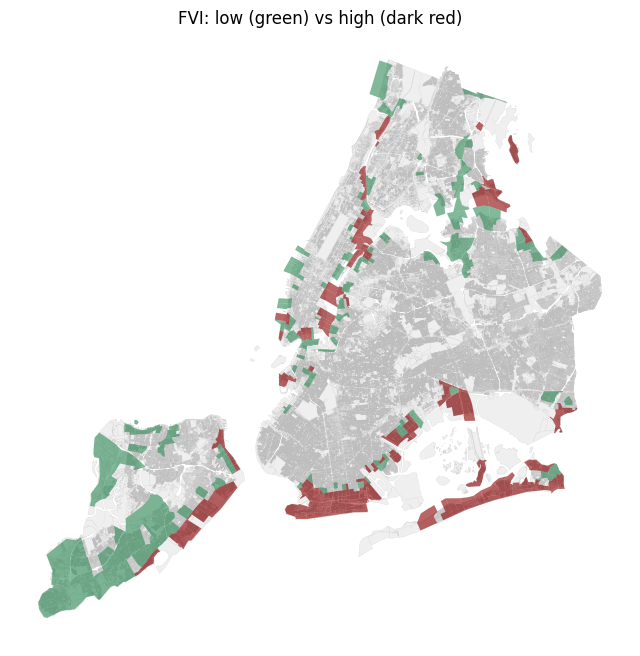

In [21]:
ax = pluto.plot(figsize=(8,8), color="#efefef", edgecolor="#bdbdbd", linewidth=0.1)
fvi_low.plot(ax=ax, color="#2E8B57", alpha=0.6, linewidth=0)
fvi_high.plot(ax=ax, color="#8B0000", alpha=0.6, linewidth=0)
plt.title("FVI: low (green) vs high (dark red)")
plt.axis("off")

(np.float64(905419.3167668581),
 np.float64(1075030.728049636),
 np.float64(113371.5741235733),
 np.float64(279446.30377368926))

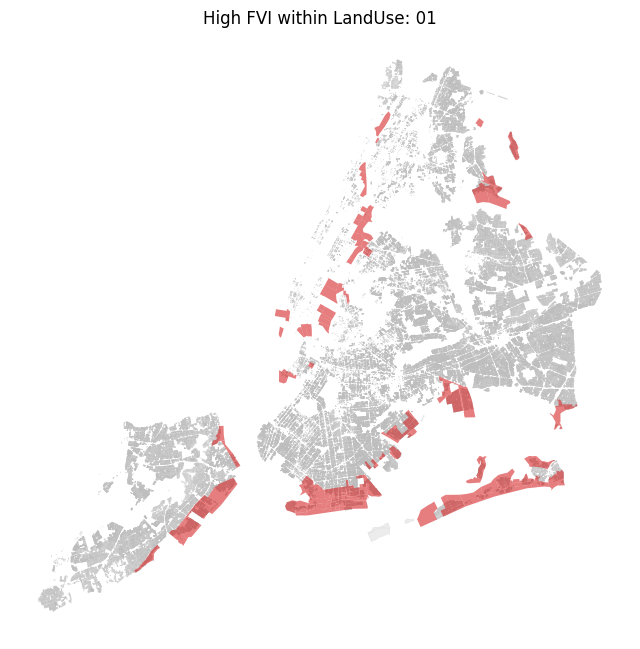

In [22]:
target_landuse = pluto.LandUse.value_counts().idxmax() if pluto.LandUse.notna().any() else None
pluto_sel = pluto[pluto.LandUse == target_landuse] if target_landuse is not None else pluto
ax = pluto_sel.plot(figsize=(8,8), color="#ececec", edgecolor="#bdbdbd", linewidth=0.1)
fvi_high.plot(ax=ax, color="#d62728", alpha=0.6, linewidth=0)
plt.title(f"High FVI within LandUse: {str(target_landuse)}")
plt.axis("off")

(np.float64(905418.5751214505),
 np.float64(1075046.302603197),
 np.float64(112410.87610433102),
 np.float64(280449.29290821555))

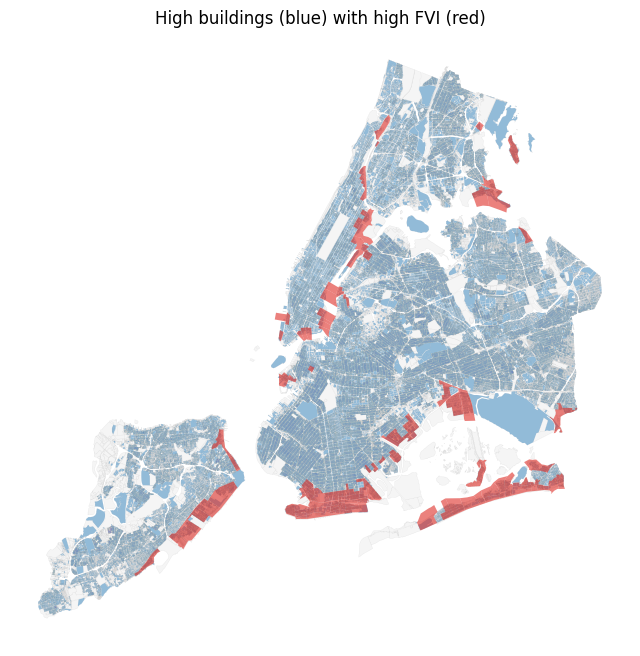

In [23]:
floors = pluto["NumFloors"].dropna()
q1, q2 = floors.quantile([0.33, 0.66]) if len(floors) > 0 else (0,0)
pluto_high_bldg = pluto[pluto["NumFloors"] >= q2] if len(floors) > 0 else pluto
ax = pluto.plot(figsize=(8,8), color="#f5f5f5", edgecolor="#cfcfcf", linewidth=0.1)
pluto_high_bldg.plot(ax=ax, color="#3182bd", alpha=0.5, linewidth=0)
fvi_high.plot(ax=ax, color="#de2d26", alpha=0.6, linewidth=0)
plt.title("High buildings (blue) with high FVI (red)")
plt.axis("off")